Thư viện

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.fft import fft, fftfreq
from scipy.stats import skew, kurtosis
from scipy.signal import butter, filtfilt #bandpass filter

In [2]:
df_0Nm_BPFI_03 = pd.read_csv('Vibration data/0Nm_BPFI_03.csv') 
df_0Nm_BPFI_10 = pd.read_csv('Vibration data/0Nm_BPFI_10.csv')
df_0Nm_BPFO_03 = pd.read_csv('Vibration data/0Nm_BPFO_03.csv')
df_0Nm_BPFO_10 = pd.read_csv('Vibration data/0Nm_BPFO_10.csv')
df_0Nm_Misalign_01 = pd.read_csv('Vibration data/0Nm_Misalign_01.csv')
df_0Nm_Misalign_03 = pd.read_csv('Vibration data/0Nm_Misalign_03.csv')
df_0Nm_Normal = pd.read_csv('Vibration data/0Nm_Normal.csv')
df_0Nm_Unbalance_0583mg = pd.read_csv('Vibration data/0Nm_Unbalance_0583mg.csv')
df_0Nm_Unbalance_1169mg = pd.read_csv('Vibration data/0Nm_Unbalance_1169mg.csv')
df_2Nm_BPFI_03 = pd.read_csv('Vibration data/2Nm_BPFI_03.csv') 
df_2Nm_BPFI_10 = pd.read_csv('Vibration data/2Nm_BPFI_10.csv')
df_2Nm_BPFO_03 = pd.read_csv('Vibration data/2Nm_BPFO_03.csv')
df_2Nm_BPFO_10 = pd.read_csv('Vibration data/2Nm_BPFO_10.csv')
df_2Nm_Misalign_01 = pd.read_csv('Vibration data/2Nm_Misalign_01.csv')
df_2Nm_Misalign_03 = pd.read_csv('Vibration data/2Nm_Misalign_03.csv')
df_2Nm_Normal = pd.read_csv('Vibration data/2Nm_Normal.csv')
df_2Nm_Unbalance_0583mg = pd.read_csv('Vibration data/2Nm_Unbalance_0583mg.csv')
df_2Nm_Unbalance_1169mg = pd.read_csv('Vibration data/2Nm_Unbalance_1169mg.csv')
df_4Nm_BPFI_03 = pd.read_csv('Vibration data/4Nm_BPFI_03.csv') 
df_4Nm_BPFI_10 = pd.read_csv('Vibration data/4Nm_BPFI_10.csv')
df_4Nm_BPFO_03 = pd.read_csv('Vibration data/4Nm_BPFO_03.csv')
df_4Nm_BPFO_10 = pd.read_csv('Vibration data/4Nm_BPFO_10.csv')
df_4Nm_Misalign_01 = pd.read_csv('Vibration data/4Nm_Misalign_01.csv')
df_4Nm_Misalign_03 = pd.read_csv('Vibration data/4Nm_Misalign_03.csv')
df_4Nm_Normal = pd.read_csv('Vibration data/4Nm_Normal.csv')
df_4Nm_Unbalance_0583mg = pd.read_csv('Vibration data/4Nm_Unbalance_0583mg.csv')
df_4Nm_Unbalance_1169mg = pd.read_csv('Vibration data/4Nm_Unbalance_1169mg.csv')

In [3]:
print(df_0Nm_BPFI_03.shape)
print(df_0Nm_Unbalance_0583mg.shape)
print(df_4Nm_Normal.shape)
print(df_4Nm_Misalign_01.shape)



(1536000, 4)
(3071999, 4)
(3072000, 4)
(3072000, 4)


định nghĩa tiền xử lý

In [4]:
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def normalize_zscore(x):
    mu = np.mean(x)
    sigma = np.std(x)
    if sigma == 0:
        return x - mu
    return (x - mu) / sigma

def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))
    #return (data) / (np.max(data) - np.min(data))
    #return 2 * (data - np.min(data)) / (np.max(data) - np.min(data)) - 1

def windowing(data, window_size, step_size):
    windows = []
    for start in range(0, len(data) - window_size + 1, step_size):
        windows.append(data[start:start + window_size])
    return np.array(windows)


Định nghĩa hàm trích xuất đặc trưng miền thời gian

In [5]:
def time_domain_features(window):
    Mean_time = np.mean(window)
    RMS_time = np.sqrt(np.mean(window**2))
    MAX = np.max(window)
    MIN = np.min(window)
    PTP = MAX - MIN
    CREST_FACTOR = MAX / RMS_time
    
    return [Mean_time, RMS_time, MAX, MIN, PTP, CREST_FACTOR]

Định nghĩa hàm trích xuất đặc trưng miền tần số

In [ ]:
def frequency_domain_features(window, fs):
    # Biến đổi FFT
    N = len(window)
    Y = np.abs(fft(window))[:N//2]
    f = fftfreq(N, 1/fs)[:N//2]
    Y_norm = Y / np.sum(Y)
 
     # Các đặc trưng F1 - F10
    Mean_freq = np.mean(Y)# Mean frequency
    Var = np.var(Y) # Variance
    Skewness = skew(Y)# Skewness
    Kurtosis = kurtosis(Y)# Kurtosis
    Central = np.sum(f * Y) / np.sum(Y)# Central frequency
    STD = np.sqrt(np.sum(((f - Central)**2) * Y) / np.sum(Y)) #STD frequency
    RMS_freq = np.sqrt(np.sum(f**2 * Y) / np.sum(Y))# RMS frequency
    Spectral_centroid = np.sum(np.arange(len(Y)) * Y) / np.sum(Y)#Spectral centroid
    Spectral_spread = np.sqrt(np.sum(((np.arange(len(Y)) - Spectral_centroid)**2) * Y) / np.sum(Y)) #Spectral spread
    Spectral_entropy = -np.sum(Y_norm * np.log2(Y_norm + 1e-12)) #Spectral entropy

    return [Mean_freq, RMS_freq, Var, Skewness, Kurtosis, Central, STD,  Spectral_centroid, Spectral_spread, Spectral_entropy]

In [7]:
files = {"Vibration data/0Nm_BPFI_03.csv": "BPFI_03",
        "Vibration data/2Nm_BPFI_03.csv": "BPFI_03",
        "Vibration data/4Nm_BPFI_03.csv": "BPFI_03",
        "Vibration data/0Nm_BPFI_10.csv": "BPFI_10",
        "Vibration data/2Nm_BPFI_10.csv": "BPFI_10",
        "Vibration data/4Nm_BPFI_10.csv": "BPFI_10",
        "Vibration data/0Nm_BPFO_03.csv": "BPFO_03",
        "Vibration data/2Nm_BPFO_03.csv": "BPFO_03",
        "Vibration data/4Nm_BPFO_03.csv": "BPFO_03",
        "Vibration data/0Nm_BPFO_10.csv": "BPFO_10",
        "Vibration data/2Nm_BPFO_10.csv": "BPFO_10",
        "Vibration data/4Nm_BPFO_10.csv": "BPFO_10",
        "Vibration data/0Nm_Misalign_01.csv": "Misalign_01",
        "Vibration data/2Nm_Misalign_01.csv": "Misalign_01",
        "Vibration data/4Nm_Misalign_01.csv": "Misalign_01",
        "Vibration data/0Nm_Misalign_03.csv": "Misalign_03",
        "Vibration data/2Nm_Misalign_03.csv": "Misalign_03",
        "Vibration data/4Nm_Misalign_03.csv": "Misalign_03",
        "Vibration data/0Nm_Unbalance_0583mg.csv": "Unbalance_0583mg",
        "Vibration data/2Nm_Unbalance_0583mg.csv": "Unbalance_0583mg",
        "Vibration data/4Nm_Unbalance_0583mg.csv": "Unbalance_0583mg",
        "Vibration data/0Nm_Unbalance_1169mg.csv": "Unbalance_1169mg",
        "Vibration data/2Nm_Unbalance_1169mg.csv": "Unbalance_1169mg",
        "Vibration data/4Nm_Unbalance_1169mg.csv": "Unbalance_1169mg",
        "Vibration data/0Nm_Normal.csv": "Normal",
        "Vibration data/2Nm_Normal.csv": "Normal",
        "Vibration data/4Nm_Normal.csv": "Normal"
        }

Thông số đầu vào

In [9]:
fs= 25600  #tần số lấy mẫu
lowcut = 10  #tần số cắt thấp
highcut = 5000 #tần số cắt cao
window_size = 2**11  #số mẫu mỗi đoạn
step_size = int((2**11)/2)  #bước nhảy


Lặp lại cho tất cả các file và trích xuất đặc trưng

In [157]:
all_features = []

for file, label in files.items():
    df = pd.read_csv(file, header= None, skiprows=1)
    data = df.iloc[:, 0].values # Lấy cột đầu tiên (index = 0)

#Tiền xử lý
    filtered_data = bandpass_filter(data, lowcut, highcut, fs)
    normalized_data = normalize(filtered_data)
    normalized_data = normalized_data - np.mean(normalized_data)
    windows = windowing(normalized_data, window_size, step_size)

#Tính đặc trưng 
    time_feats = [time_domain_features(window) for window in windows]
    freq_feats = [frequency_domain_features(window,fs) for window in windows]
    
    time_cols = ["Mean_time", "RMS_time", "MAX", "MIN", "PTP", "CREST_FACTOR"]
    freq_cols = ["Mean_freq", "RMS_freq", "Var", "Skewness", "Kurtosis", "Central", "STD", "Spectral_centroid", "Spectral_spread", "Spectral_entropy"]
    

#Tạo DataFrame có tên cột
    df_time = pd.DataFrame(time_feats, columns=time_cols)
    df_freq = pd.DataFrame(freq_feats, columns=freq_cols)

# Gộp lại
    features = pd.concat([df_time, df_freq], axis=1)    
    features["label"]=label
    all_features.append(features)


Xem cách chia đoạn tín hiệu 

In [11]:
all_features = []
for file, label in files.items():
    df = pd.read_csv(file, header=None, skiprows=1)
    data = df.iloc[:, 0].values  # Toàn bộ tín hiệu 1 file

    # Tiền xử lý
    filtered_data = bandpass_filter(data, lowcut, highcut, fs)
    normalized_data = normalize(filtered_data)
    normalized_data = normalized_data - np.mean(normalized_data)

    # Tính đặc trưng toàn tín hiệu (không chia window)
    time_feats = time_domain_features(normalized_data)
    freq_feats = frequency_domain_features(normalized_data, fs)

    # Tạo DataFrame có một hàng
    time_cols = ["Mean_time", "RMS_time", "MAX", "MIN", "PTP", "CREST_FACTOR"]
    freq_cols = ["Mean_freq", "RMS_freq", "Var", "Skewness", "Kurtosis", 
                 "Central", "STD", "Spectral_centroid", "Spectral_spread", "Spectral_entropy"]

    df_time = pd.DataFrame([time_feats], columns=time_cols)
    df_freq = pd.DataFrame([freq_feats], columns=freq_cols)

    # Gộp và thêm nhãn
    features = pd.concat([df_time, df_freq], axis=1)
    features["label"] = label
    all_features.append(features)
all_features_df = pd.concat(all_features, ignore_index=True)
all_features_df.to_csv("testnowindow.csv", index=False)


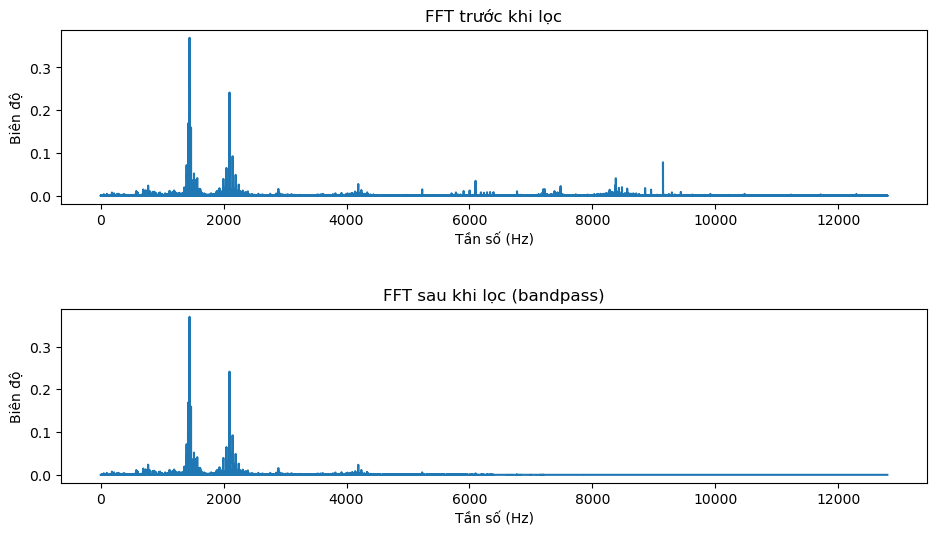

In [121]:
import matplotlib.pyplot as plt #vẽ đồ thị
def compute_fft(signal, fs):
    N = len(signal)
    freq = np.fft.rfftfreq(N, 1/fs)
    fft_mag = np.abs(np.fft.rfft(signal)) / N
    return freq, fft_mag

freq, fft_before = compute_fft(data, fs)
_, fft_after = compute_fft(filtered_data, fs)

# --- Plot ---
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(freq, fft_before)
plt.title('FFT trước khi lọc')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ')


plt.subplot(2, 1, 2)
plt.plot(freq, fft_after)
plt.title('FFT sau khi lọc (bandpass)')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ')
plt.tight_layout(pad=3)
plt.show()

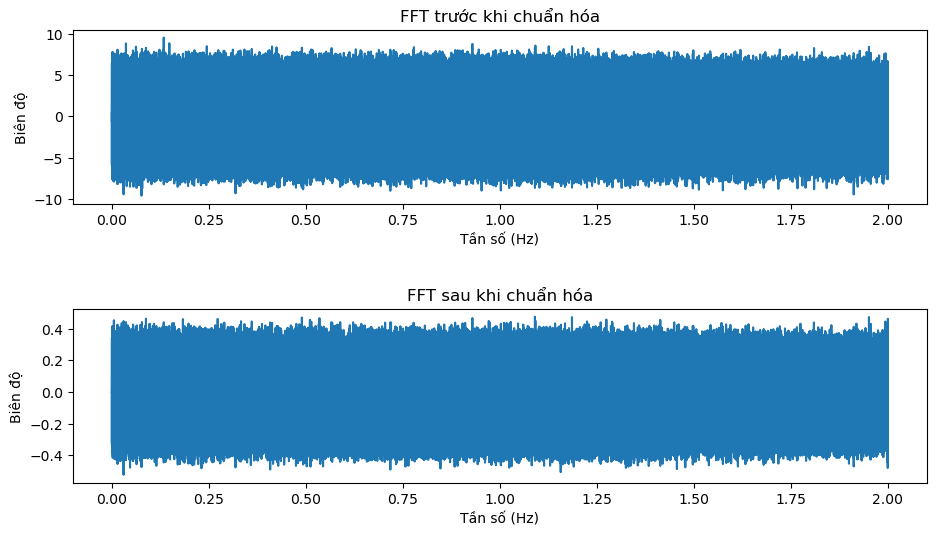

In [146]:
Time = np.arange(len(data)) / fs
# Vẽ dữ liệu dao động
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(Time/60, data)
plt.title('FFT trước khi chuẩn hóa')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ')


plt.subplot(2, 1, 2)
plt.plot(Time/60, normalized_data)
plt.title('FFT sau khi chuẩn hóa')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ')
plt.tight_layout(pad=3)
plt.show()

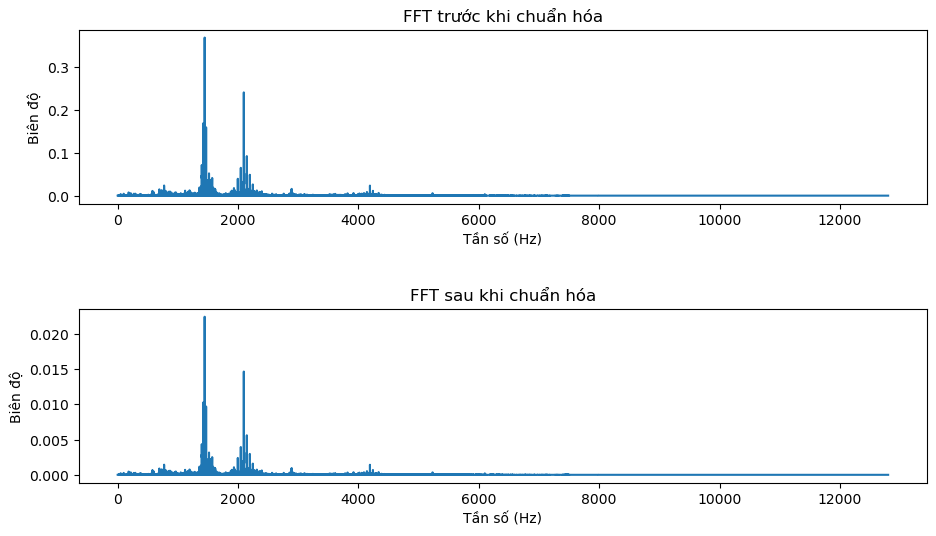

In [147]:
freq, fft_before = compute_fft(filtered_data, fs)
_, fft_after = compute_fft(normalized_data, fs)

# --- Plot ---
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(freq, fft_before)
plt.title('FFT trước khi chuẩn hóa')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ')


plt.subplot(2, 1, 2)
plt.plot(freq, fft_after)
plt.title('FFT sau khi chuẩn hóa')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ')
plt.tight_layout(pad=3)
plt.show()

In [ ]:
all_features_df = pd.concat(all_features, ignore_index=True)
all_features_df.to_csv("[constant speed]features.csv", index=False)
